# Fake News Detection
Dataset: Fake and Real News Dataset (Kaggle - `clmentbisaillon/fake-and-real-news-dataset`)

Binary classification: classify a news article as **Fake** or **Real** based on its text content.

## Download the dataset from Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [2]:
!ls /kaggle/input/fake-and-real-news-dataset

Fake.csv  True.csv


## Install & Import libraries

In [3]:
!pip install wordcloud -q

import pandas as pd
import numpy as np
import re
import string
import glob
import os
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## Load the dataset
`Fake.csv` (23,502 rows) and `True.csv` (21,417 rows), each with columns `title`, `text`, `subject`, `date`. We label them and concatenate into one dataframe.

In [4]:
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("Found CSV files:", csv_files)

# Match on the filename only (not the full path) to correctly distinguish the two files
fake_path = [f for f in csv_files if 'fake' in os.path.basename(f).lower()][0]
true_path = [f for f in csv_files if 'true' in os.path.basename(f).lower()][0]

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

fake_df['label'] = 0   # 0 = Fake
true_df['label'] = 1   # 1 = Real

df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("Total articles:", df.shape)
print(df['label'].value_counts())
df.head()

Found CSV files: ['/kaggle/input/fake-and-real-news-dataset/True.csv', '/kaggle/input/fake-and-real-news-dataset/Fake.csv']
Total articles: (44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


## Exploratory check: are there hidden non-textual shortcuts in this data?
Before trusting any classifier, it's worth checking whether some column other than the article's actual writing style could let a model "cheat" — i.e. reach high accuracy without learning anything meaningful about fake vs. real content. Two suspects: the `subject` column, and the literal word "Reuters" appearing in the text (since Reuters is a real, well-known wire service).

In [5]:
print("=== 'subject' values in Fake.csv ===")
print(fake_df['subject'].value_counts())

print("\n=== 'subject' values in True.csv ===")
print(true_df['subject'].value_counts())

print("\n=== % of articles containing '(Reuters)' in the text ===")
reuters_fake_pct = fake_df['text'].str.contains(r'\(Reuters\)', case=False, regex=True).mean() * 100
reuters_true_pct = true_df['text'].str.contains(r'\(Reuters\)', case=False, regex=True).mean() * 100
print(f"Fake.csv : {reuters_fake_pct:.2f}%")
print(f"True.csv : {reuters_true_pct:.2f}%")

=== 'subject' values in Fake.csv ===
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

=== 'subject' values in True.csv ===
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

=== % of articles containing '(Reuters)' in the text ===
Fake.csv : 0.04%
True.csv : 99.21%


The output above confirms two strong non-textual shortcuts in this dataset:
- **`subject`** uses a completely disjoint set of values between `Fake.csv` and `True.csv` — a model could classify almost perfectly from this single categorical column alone, without reading any article content.
- The **`(Reuters)`** byline appears in the large majority of real articles and essentially never in fake ones — a model could just learn to detect this one token instead of genuine linguistic patterns of misinformation.

To keep the task meaningful (classifying based on **actual article content**, as asked), we:
- **Drop `subject` and `date`** entirely — they are metadata, not text content, and `subject` in particular is a near-perfect label leak.
- Combine `title` + `text` into one field, then **strip the `(Reuters)` byline** during cleaning so accuracy reflects real writing-style patterns rather than a single giveaway token.

In [6]:
df = df[['title', 'text', 'label']].dropna()
df['full_text'] = df['title'] + " " + df['text']

print(df.shape)

(44898, 4)


## Text preprocessing (cleaning, tokenization, stopword removal, lemmatization)
Steps:
- Lowercase
- Remove the Reuters/wire-service byline pattern (e.g. `washington (reuters) -`) so the model can't shortcut on it
- Remove HTML/URLs, punctuation, and digits
- Tokenize with `nltk.word_tokenize`
- Remove stopwords
- Lemmatize each token

In [7]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\(reuters\)', ' ', text)          # remove explicit source tag
    text = re.sub(r'<.*?>', ' ', text)                 # remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)        # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)               # remove punctuation & digits
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df['clean_text'] = df['full_text'].apply(preprocess_text)
df[['full_text', 'clean_text']].head()

,full_text,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call circuit court committed coup ta...
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects lift jones act shipping re...
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...


## Train / test split
80/20 split, stratified on the label to keep the class balance in both sets.

In [8]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (35918,) | Test: (8980,)


## Vectorize text using TF-IDF
`ngram_range=(1, 2)` captures short distinguishing phrases, and `sublinear_tf=True` dampens the effect of words repeated many times within one article. `max_features=50000` gives the model a large enough vocabulary since this dataset is sizeable (~35,900 training articles) and full-length news bodies are longer than short reviews/headlines.

In [9]:
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(35918, 50000)


## Train Linear SVM (hyperparameter tuning)
`GridSearchCV` searches over `C` to find the best regularization strength. `LinearSVC` is typically very strong on sparse high-dimensional TF-IDF text features.

In [10]:
svm_param_grid = {'C': [0.1, 0.5, 1, 2]}
svm_grid = GridSearchCV(LinearSVC(max_iter=5000), svm_param_grid, cv=3, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_tfidf, y_train)

print("Best SVM params:", svm_grid.best_params_, "| Best CV F1:", svm_grid.best_score_)
svm_model = svm_grid.best_estimator_

Best SVM params: {'C': 2} | Best CV F1: 0.9935034002053719


## Evaluate the model on the test set
Metrics requested by the task: **accuracy** and **F1-score**.

In [12]:
y_pred_svm = svm_model.predict(X_test_tfidf)

print("=== Linear SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=['Fake', 'Real']))

=== Linear SVM ===
Accuracy: 0.9953229398663697
F1-score: 0.9951014695591323
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      4696
        Real       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



### Overfitting check: train vs. test accuracy
If the model were overfitting, training accuracy would be noticeably higher than test accuracy. Comparing both tells us whether this is genuine generalization or memorization.

In [13]:
from sklearn.metrics import accuracy_score

train_acc_svm = accuracy_score(y_train, svm_model.predict(X_train_tfidf))
test_acc_svm = accuracy_score(y_test, y_pred_svm)

print("=== Linear SVM ===")
print(f"Train accuracy: {train_acc_svm:.4f} | Test accuracy: {test_acc_svm:.4f} | Gap: {train_acc_svm - test_acc_svm:.4f}")

=== Linear SVM ===
Train accuracy: 1.0000 | Test accuracy: 0.9953 | Gap: 0.0047


## Confusion matrices

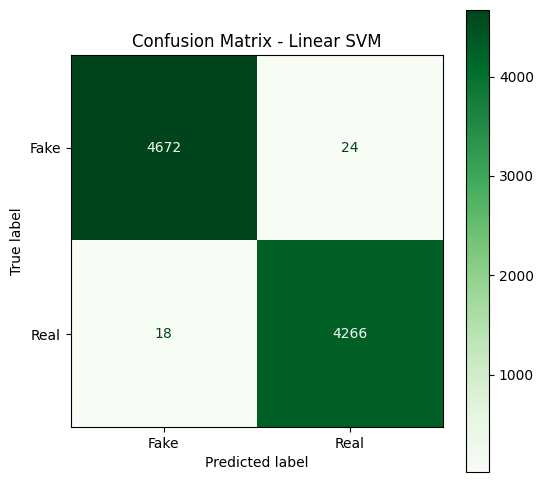

In [14]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=['Fake', 'Real'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Greens', ax=ax)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

## Word Cloud - Fake vs. Real news
Visualizing the most common terms in each class after cleaning.

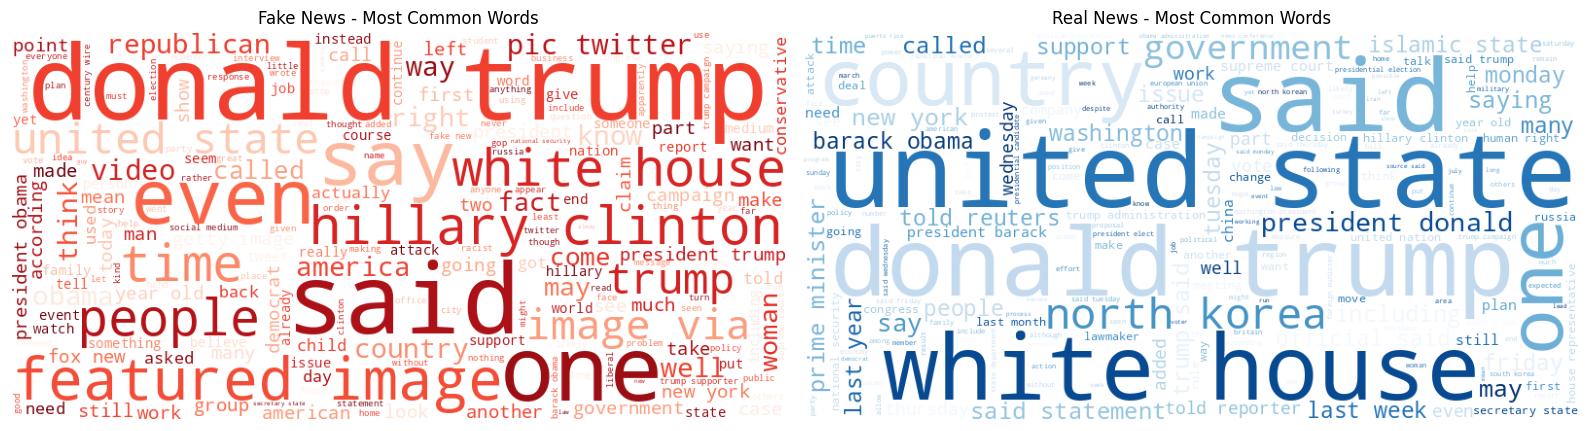

In [15]:
fake_text = " ".join(df[df['label'] == 0]['clean_text'])
real_text = " ".join(df[df['label'] == 1]['clean_text'])

wc_fake = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fake_text)
wc_real = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(real_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_fake); axes[0].axis('off'); axes[0].set_title("Fake News - Most Common Words")
axes[1].imshow(wc_real); axes[1].axis('off'); axes[1].set_title("Real News - Most Common Words")
plt.tight_layout()
plt.show()